# 01. 탐색적 데이터 분석 (EDA)

기본 통계, 변수 관계, 패턴 발견

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import platform
import warnings

warnings.filterwarnings(action='ignore')
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
	plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('axes', unicode_minus=False)

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Train: {train.shape}, Test: {test.shape}")

Train: (748, 46), Test: (814, 45)


## 1. 범주형 변수 분석

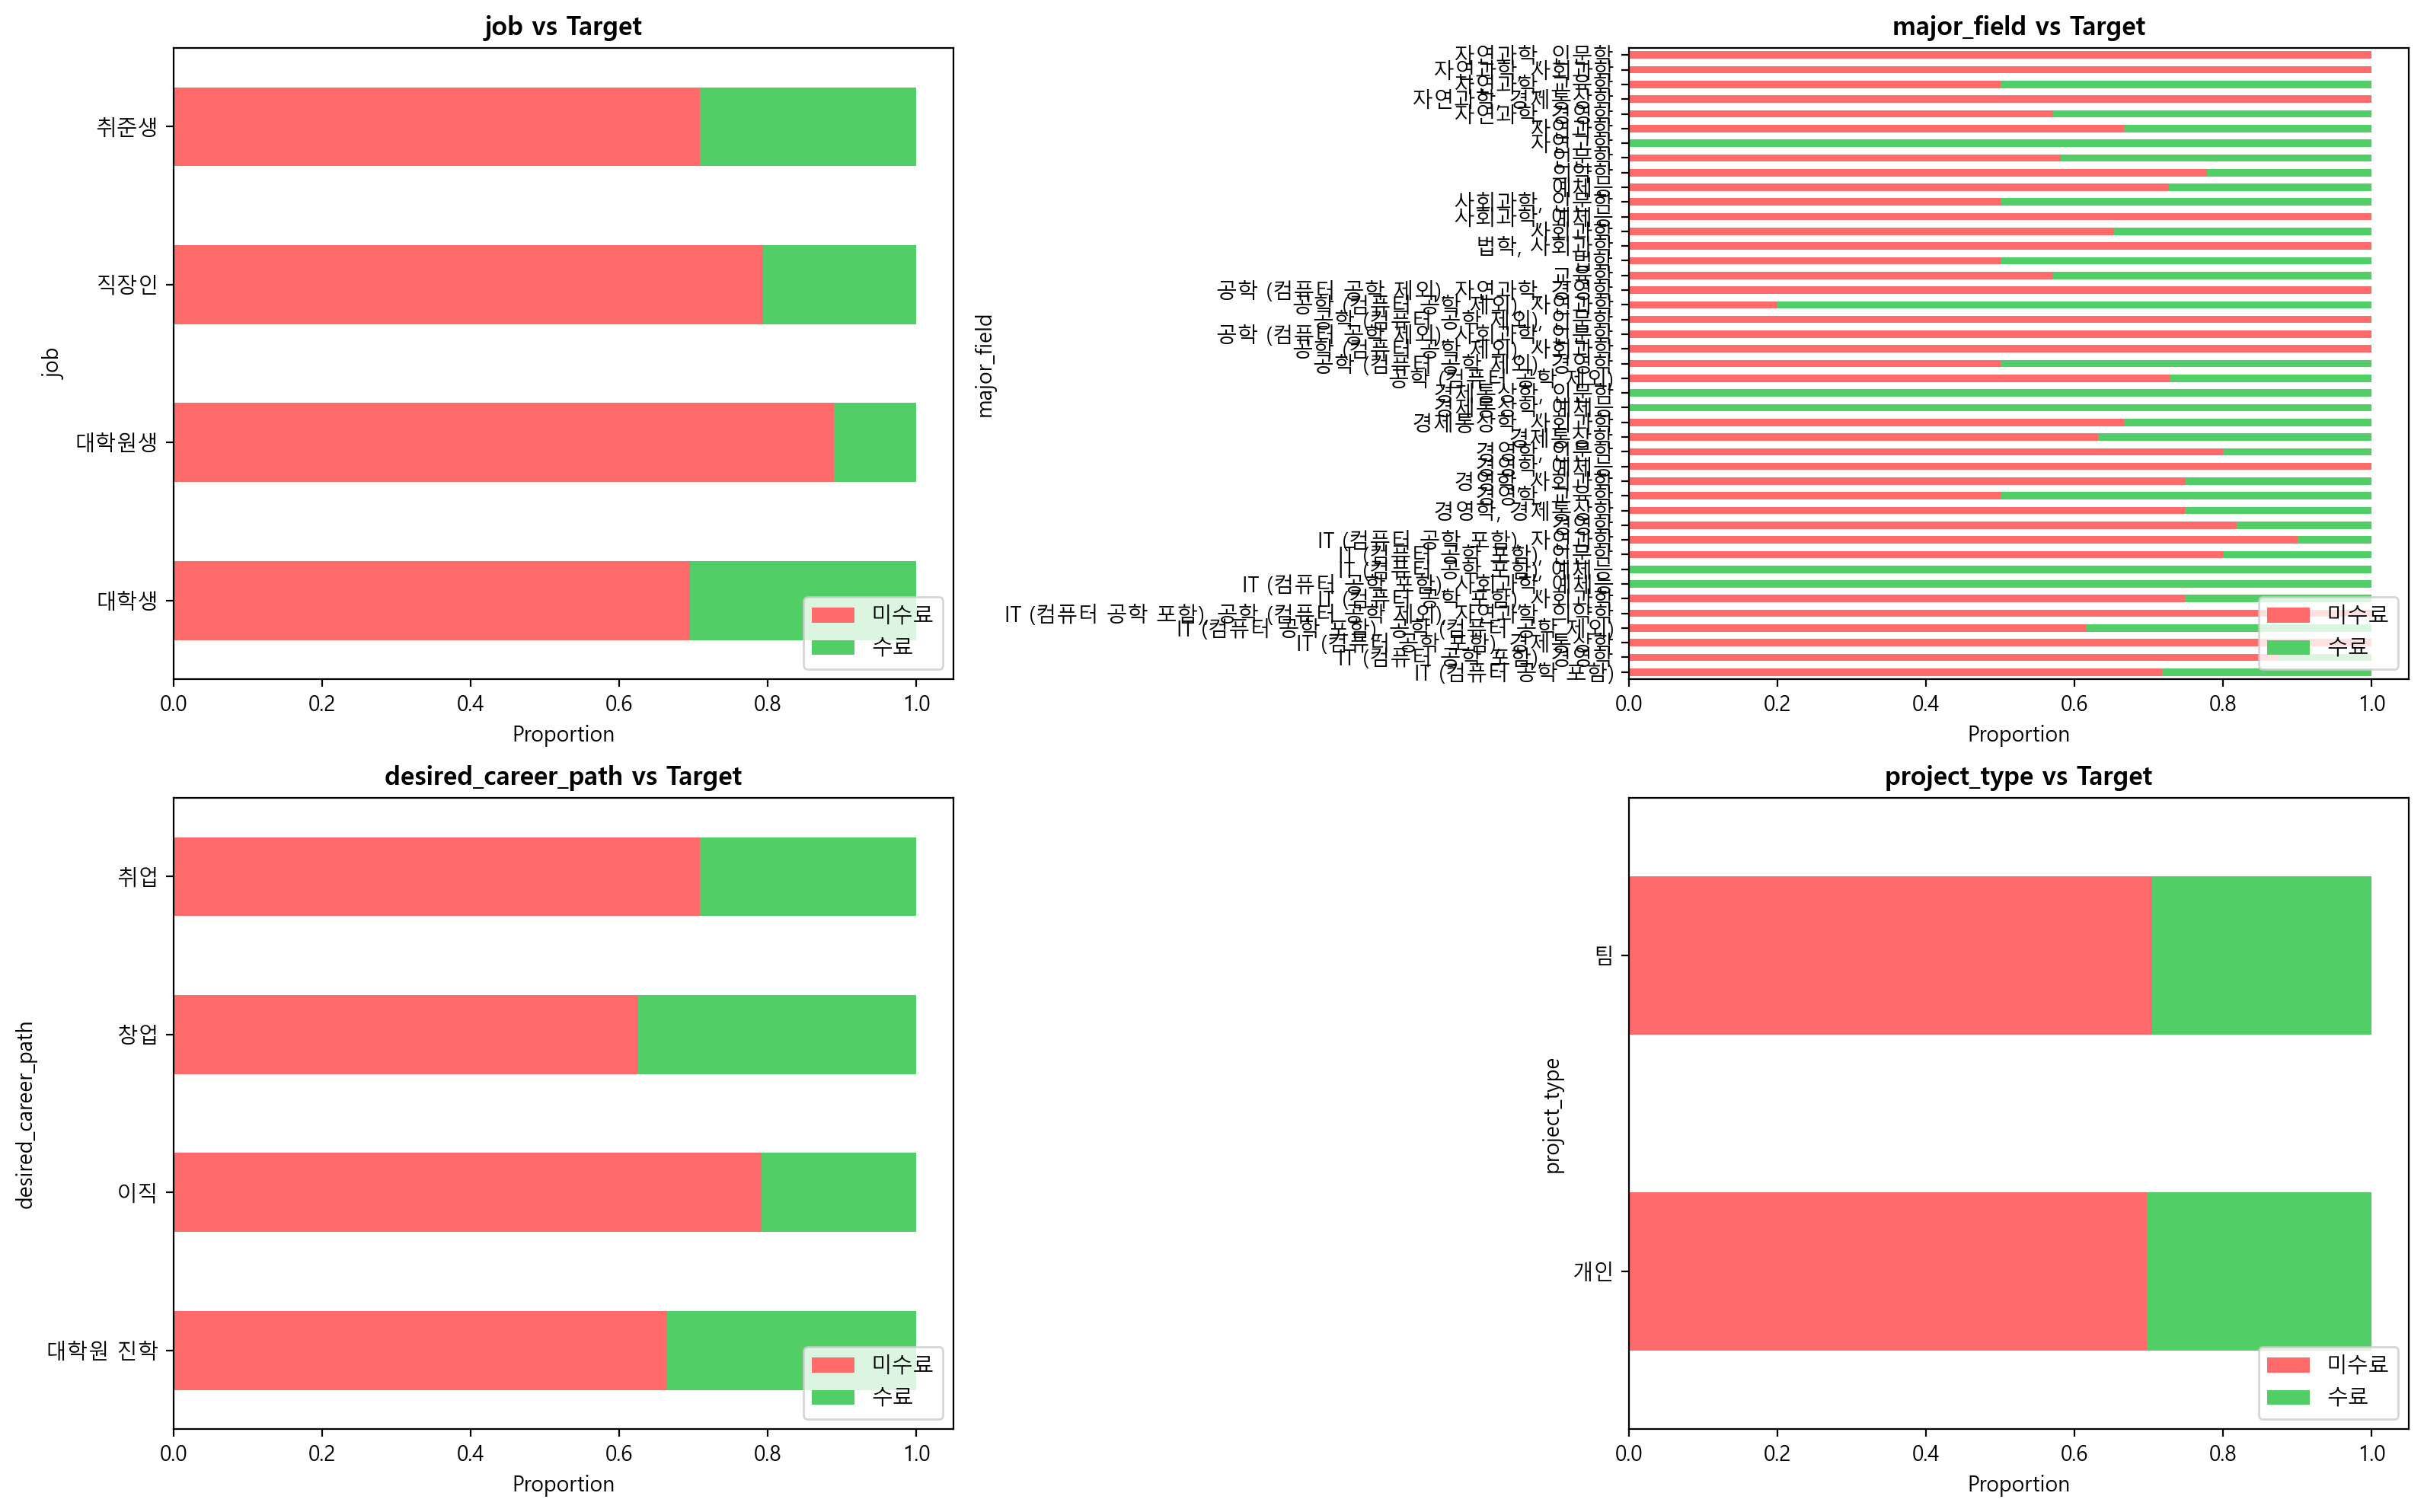

In [3]:
# 주요 범주형 변수
cat_features = ['job', 'major_field', 'desired_career_path', 'project_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    # Target별 분포
    ct = pd.crosstab(train[col], train['completed'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[idx], 
            color=['#ff6b6b', '#51cf66'])
    axes[idx].set_title(f'{col} vs Target', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Proportion')
    axes[idx].legend(['미수료', '수료'], loc='lower right')

plt.tight_layout()
plt.show()

## 2. 수치형 변수 분석

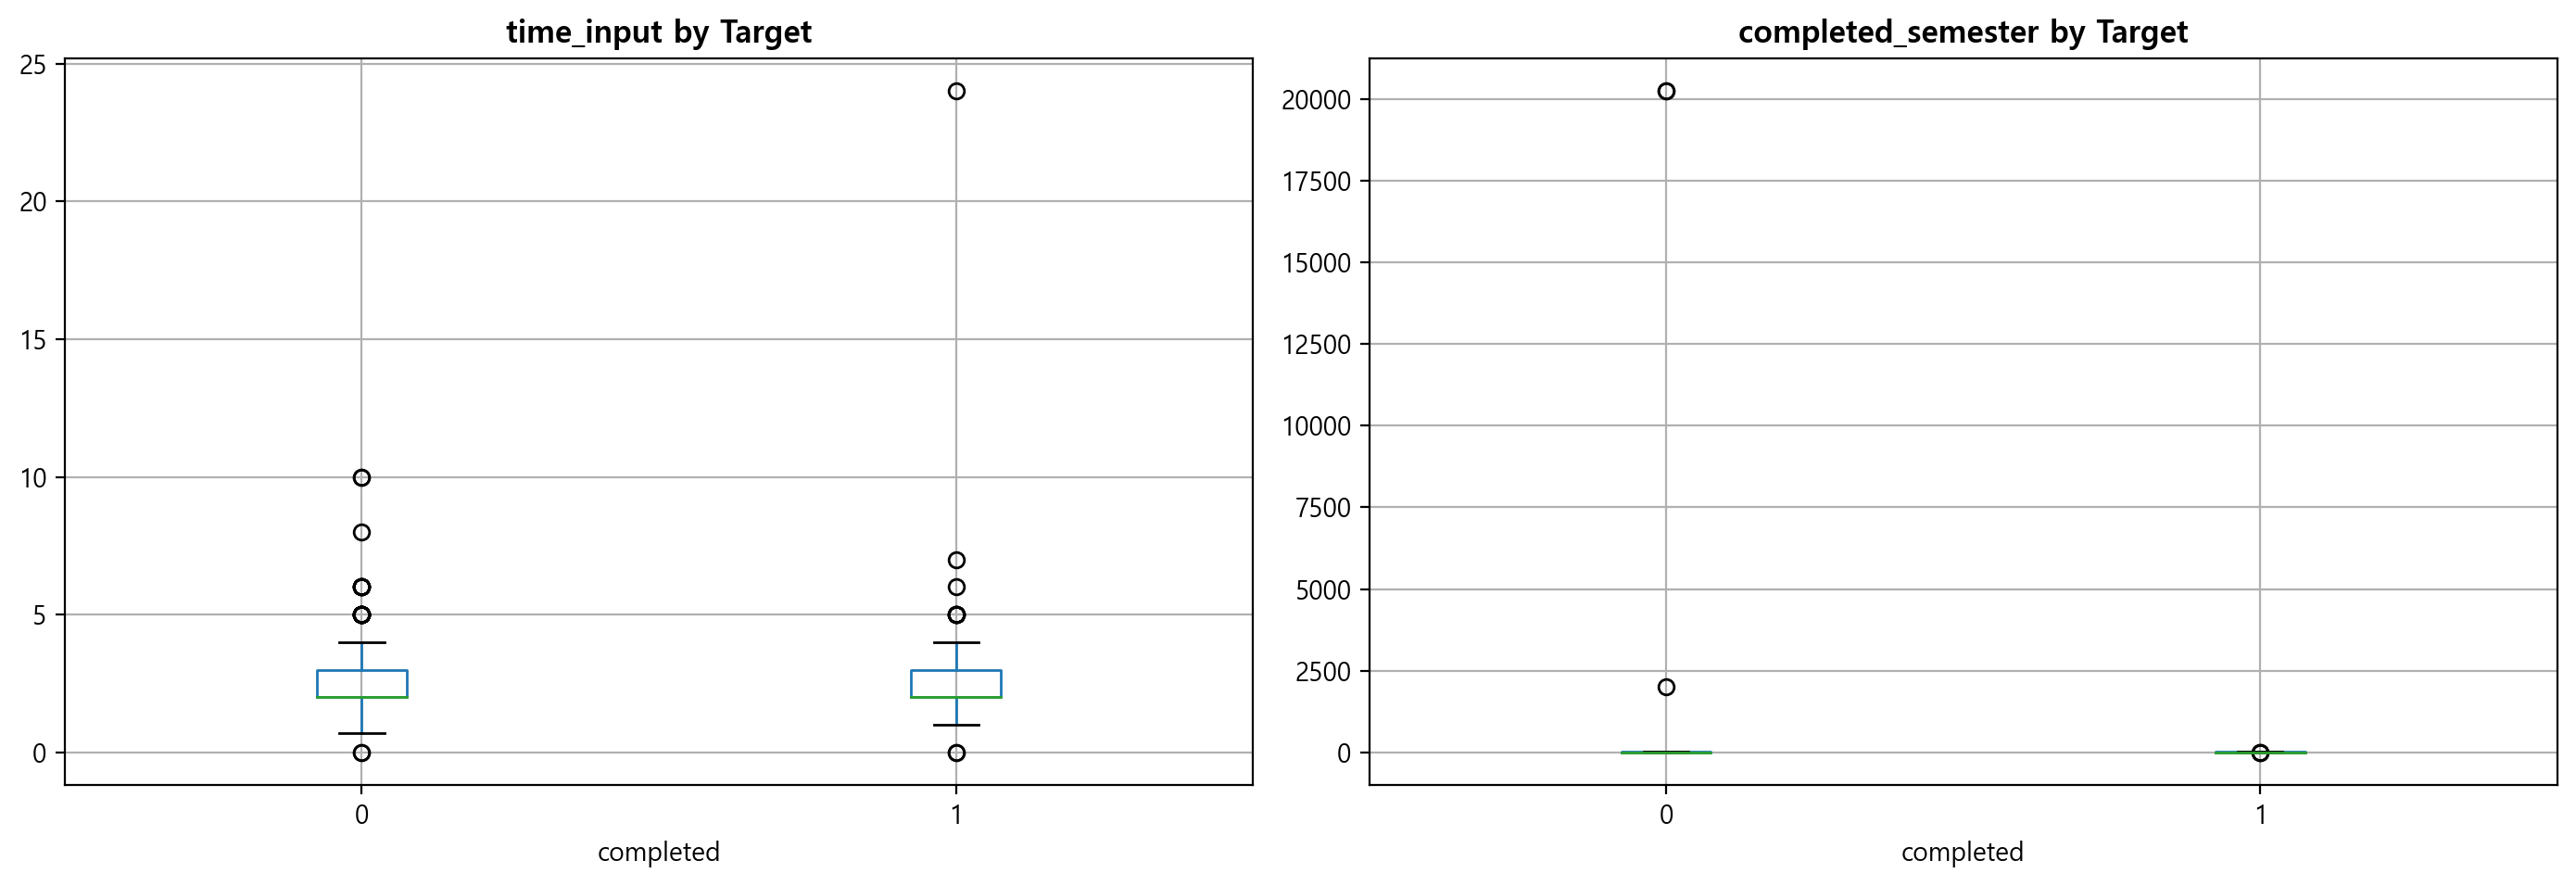

In [4]:
# 수치형 변수
num_features = ['time_input', 'completed_semester']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(num_features):
    train.boxplot(column=col, by='completed', ax=axes[idx])
    axes[idx].set_title(f'{col} by Target', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('completed')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. 페르소나 분석

major_field × job 조합

In [5]:
# 페르소나 생성
train['persona'] = train['major_field'].fillna('Unknown') + ' x ' + train['job'].fillna('Unknown')

persona_completion = train.groupby('persona').agg(
    completion_rate=('completed', 'mean'),
    count=('completed', 'count')
).round(3).sort_values('completion_rate', ascending=False)

total = len(persona_completion)
stable = persona_completion[persona_completion['count'] >= 10]

print(f"전체 페르소나 수: {total}개")
print(f"표본 10명 이상: {len(stable)}개\n")

print("수료율 상위 5개 (n >= 10):")
print(stable.head(5).to_string())

print("\n수료율 하위 5개 (n >= 10):")
print(stable.tail(5).to_string())

전체 페르소나 수: 74개
표본 10명 이상: 10개

수료율 상위 5개 (n >= 10):
                                      completion_rate  count
persona                                                     
Unknown x 대학생                                   0.500     14
인문학 x 대학생                                       0.459     37
IT (컴퓨터 공학 포함), 공학 (컴퓨터 공학 제외) x 대학생            0.417     12
경제통상학 x 대학생                                     0.353     17
사회과학 x 대학생                                      0.344     61

수료율 하위 5개 (n >= 10):
                            completion_rate  count
persona                                           
자연과학 x 대학생                            0.315     73
IT (컴퓨터 공학 포함) x 대학생                  0.293    133
공학 (컴퓨터 공학 제외) x 대학생                  0.272    114
경영학 x 대학생                             0.209     86
IT (컴퓨터 공학 포함), 자연과학 x 대학생            0.100     10


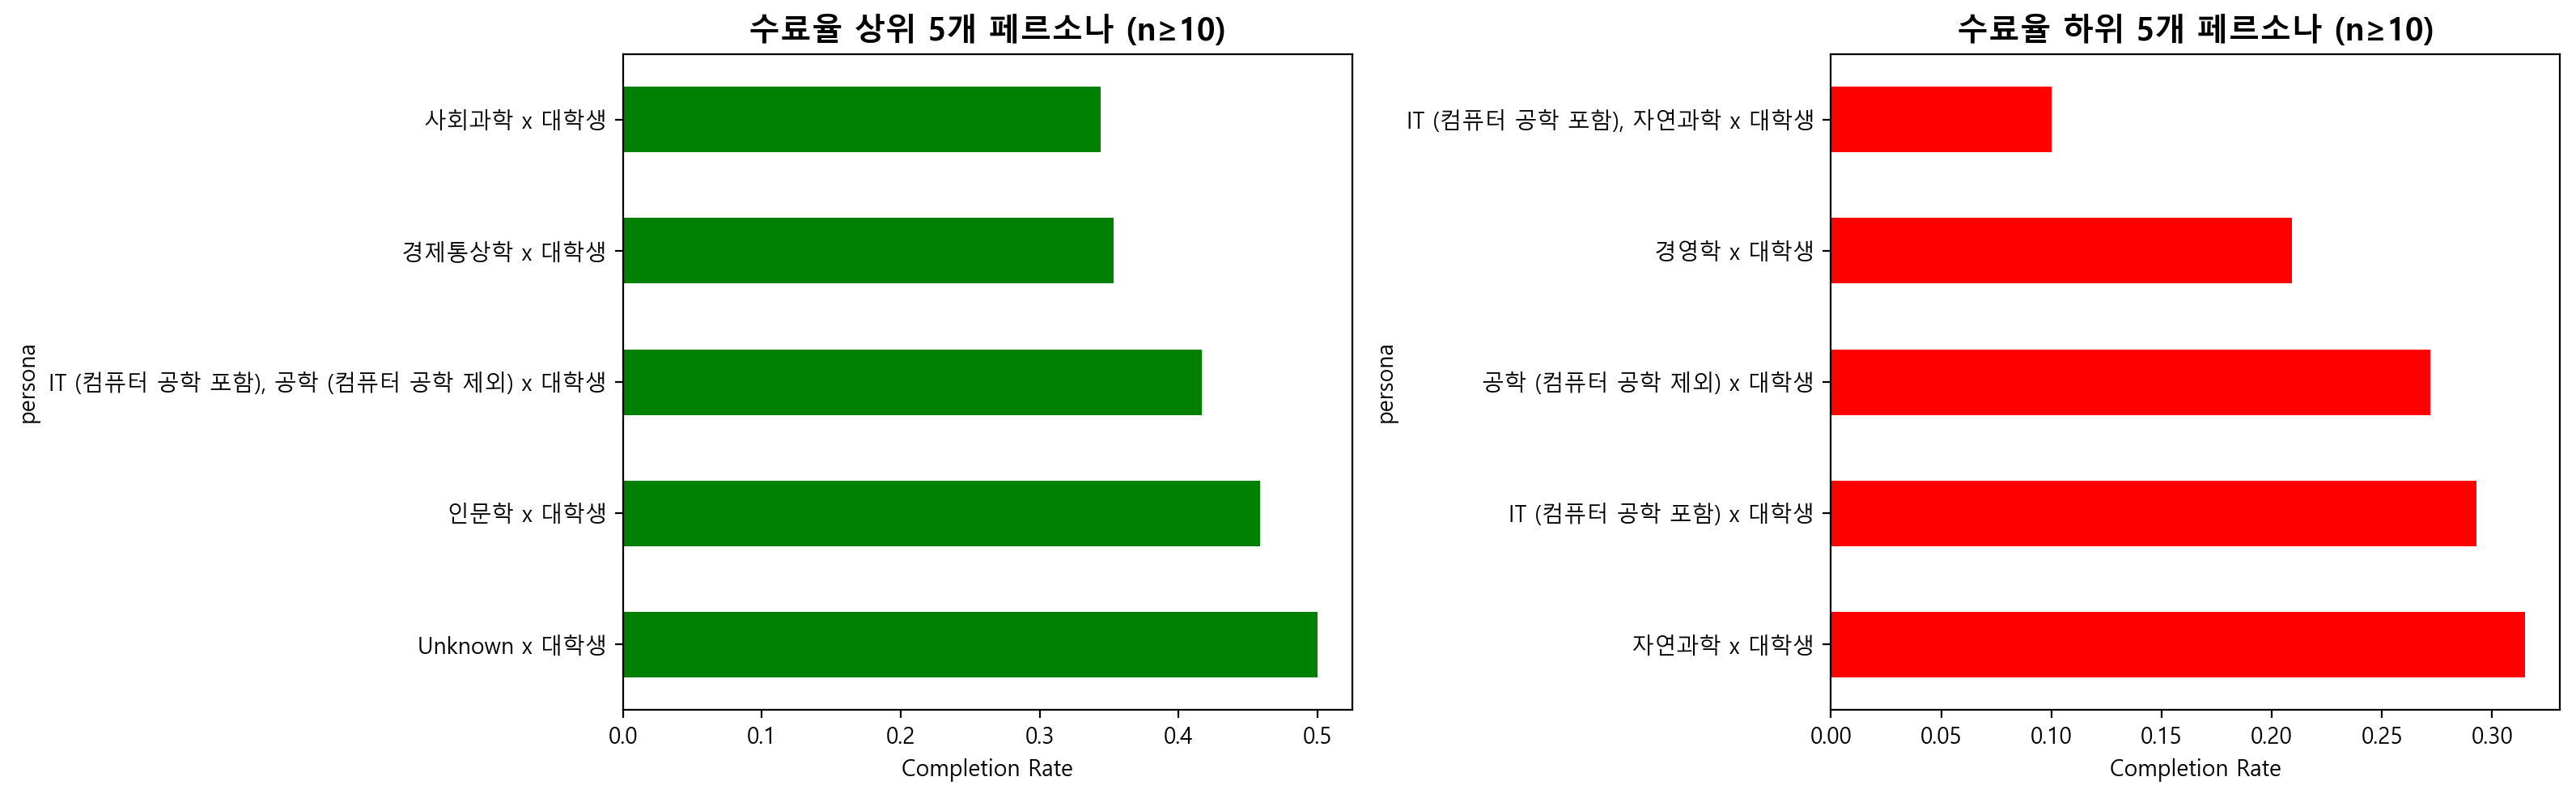

In [6]:
# 시각화 (표본 10명 이상, 상위/하위 5개)
top5 = stable.head(5)
bottom5 = stable.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top5['completion_rate'].plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('수료율 상위 5개 페르소나 (n≥10)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Completion Rate')

bottom5['completion_rate'].plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('수료율 하위 5개 페르소나 (n≥10)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Completion Rate')

plt.tight_layout()
plt.show()

## 4. 텍스트 변수 분석

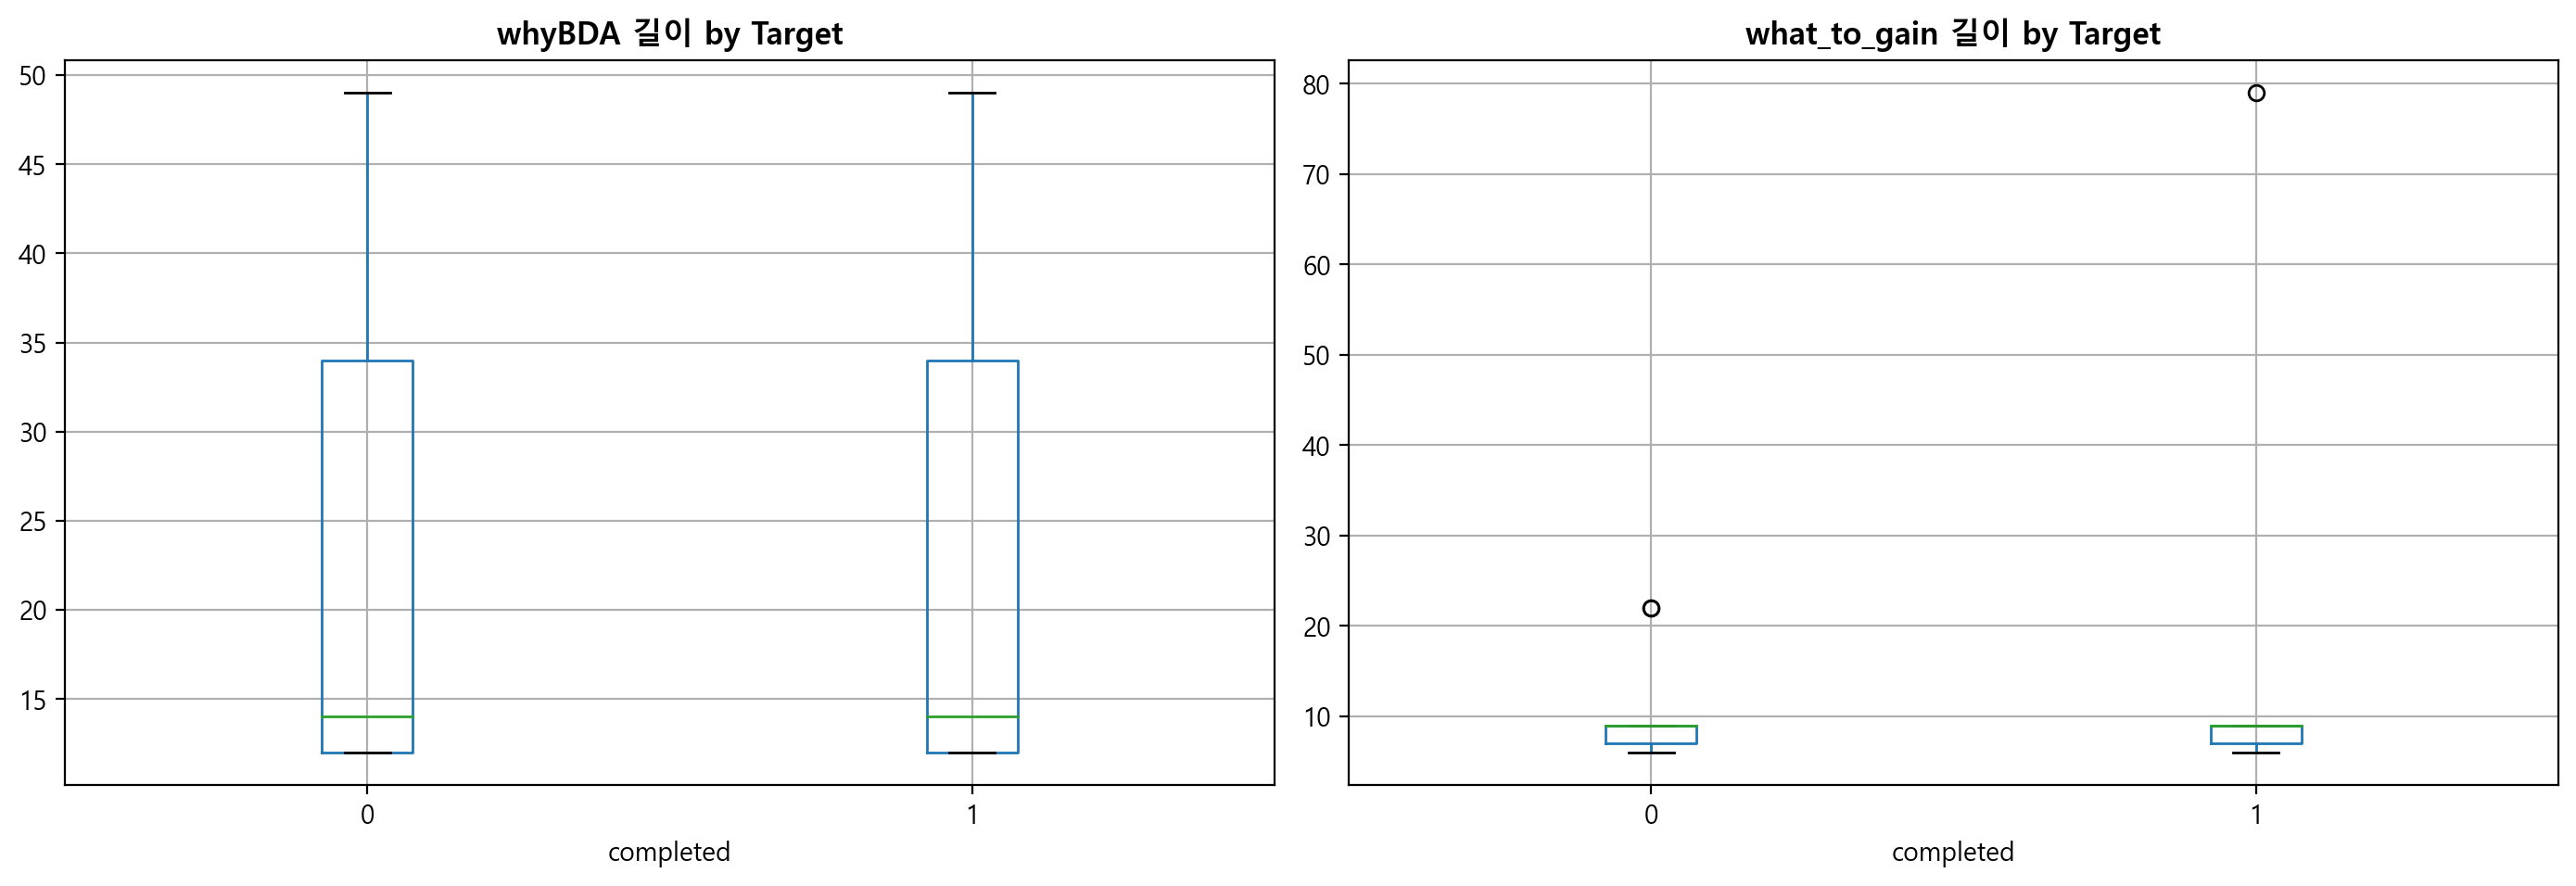

In [7]:
# 텍스트 길이
train['whyBDA_len'] = train['whyBDA'].fillna('').str.len()
train['what_to_gain_len'] = train['what_to_gain'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train.boxplot(column='whyBDA_len', by='completed', ax=axes[0])
axes[0].set_title('whyBDA 길이 by Target', fontsize=12, fontweight='bold')

train.boxplot(column='what_to_gain_len', by='completed', ax=axes[1])
axes[1].set_title('what_to_gain 길이 by Target', fontsize=12, fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [8]:
# 키워드 분석 — whyBDA + incumbents_lecture_scale_reason 합산 텍스트 사용
combined_text = train['whyBDA'].fillna('') + ' ' + train['incumbents_lecture_scale_reason'].fillna('')

keywords = ['기회', '함께', '도움', '필요', '배우', '성장', '혼자', '어려워']

for keyword in keywords:
    train[f'keyword_{keyword}'] = combined_text.str.contains(keyword).astype(int)

keyword_stats = pd.DataFrame()
for keyword in keywords:
    col = f'keyword_{keyword}'
    stats_row = train.groupby(col).agg({'completed': ['mean', 'count']})
    stats_row.columns = ['completion_rate', 'count']
    keyword_stats[keyword] = stats_row['completion_rate']

print("키워드별 수료율 (합산 텍스트 기준):")
print(keyword_stats.T)

키워드별 수료율 (합산 텍스트 기준):
keyword_기회         0         1
기회          0.295736  0.380952
함께          0.298103  0.300000
도움          0.296896  0.428571
필요          0.299329  0.000000
배우          0.297587  0.500000
성장          0.298128       NaN
혼자          0.314465  0.269373
어려워         0.313684  0.271062


## 5. 상관관계 분석

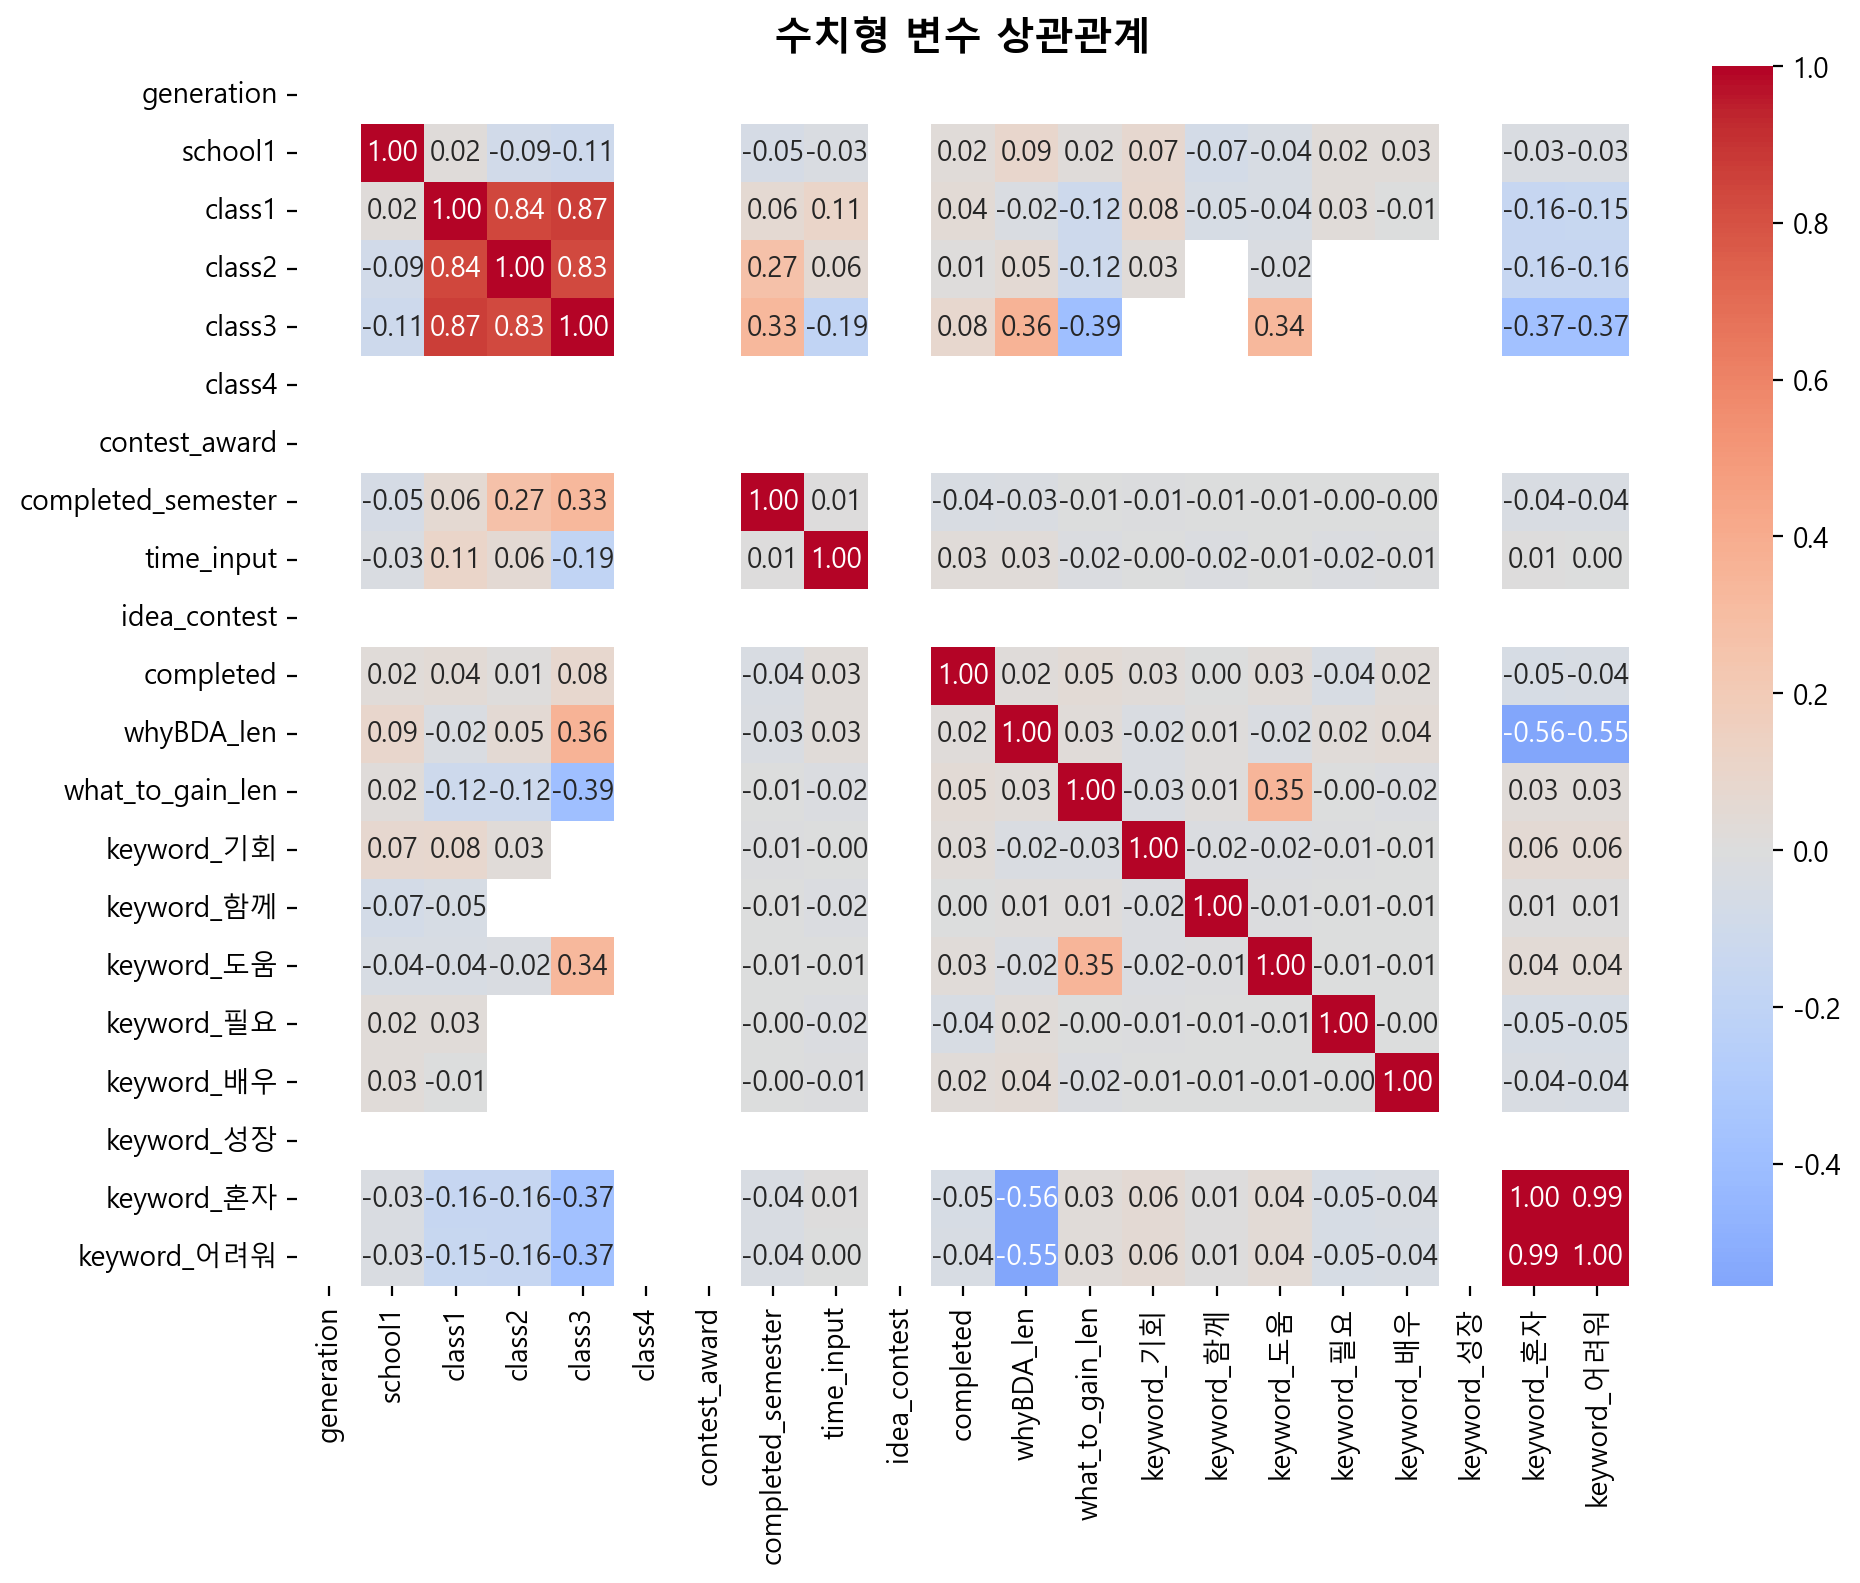

In [9]:
# 수치형 변수 상관관계
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 주요 발견사항

### 페르소나 패턴 (n ≥ 10 기준)
- 재등록자(re_registration=예)는 Train/Test 모두 안정적으로 높은 수료율
- 세부 페르소나(자연과학×취준생 등)는 표본이 9명 수준으로 신뢰 불충분
- 페르소나 변수 중 major1_1(세부전공)은 L1=1.947로 Train/Test 분포 이질성 심각 → 사용 불가

### 시간 투입
- 시간을 많이 투입할수록 수료율 증가
- time_input은 연속형 변수로 Train/Test 분포 유사 (안정적 신호)

### 텍스트 패턴
- **키워드 분석은 whyBDA + incumbents_lecture_scale_reason 합산 텍스트 기준**
- '기회', '함께' 등 키워드는 whyBDA 단독에는 거의 없고 incumbents_lecture_scale_reason에 주로 존재
- incumbents_lecture_scale_reason은 L1=1.788로 불안정 → 키워드 신호의 일반화 한계

### 다음 단계
- Train/Test 분포 비교 필요 (02_train_test_drift.ipynb)
- Lift 분석으로 통계 검증 (03_lift_analysis.ipynb)